# Week 6 Assignment
*Chapter 7 Excercises (Sec 7.3)*

## Story 1 - Two-Sample t-Test: Evaluating the Effectiveness of a New Diet Plan
A nutritionist wants to determine whether a new diet plan significantly affects the weight loss of
individuals compared to a traditional diet. The nutritionist collects weight loss data (in kg) from two
different groups of randomly selected 25 participants:
- Group A: Participants following the new diet plan.
- Group B: Participants following the traditional diet plan.

The goal is to determine whether the average weight loss differs significantly between the two groups
using a two-sample t-test.

1. **Formulate hypotheses.**

Null Hypothesis $H_0$: There is no significant difference in weight loss between individuals using a traditional diet and those using the new diet plan

$\mu_{traditional} = \mu_{new}$

Alternative Hypothesis $H_1$: The weight loss in individuals using the new diet plan is significantly greator than that of those using a traditional diet.

$\mu_{traditional} < \mu_{new}$

2. **Use Python to generate 25 random data points for each group. Assume that Group A (new diet) has
a mean weight loss of 5 kg with a standard deviation of 1.5 kg, and Group B (traditional diet) has a
mean weight loss of 4 kg with a standard deviation of 1.5 kg.**

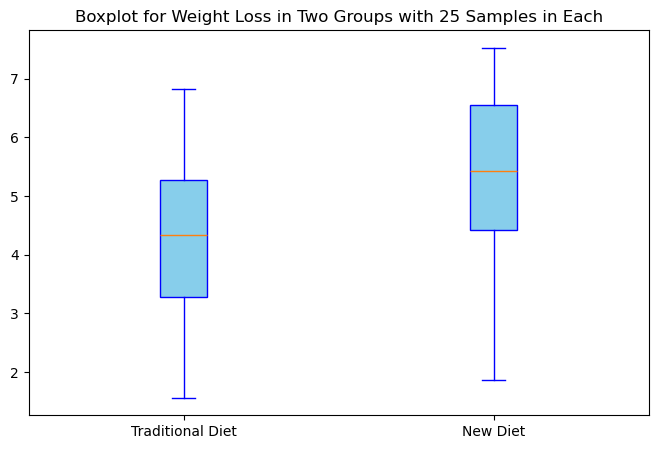

In [31]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(24)

n_Trad, n_New = 25, 25
mu_Trad, mu_New = 4.0, 5.0
sigma_Trad, sigma_New = 1.5, 1.5

sample_Trad = np.random.normal(mu_Trad, sigma_Trad, n_Trad)
sample_New = np.random.normal(mu_New, sigma_New, n_New)

plt.figure(figsize=(8, 5))
plt.boxplot([sample_Trad, sample_New], tick_labels=["Traditional Diet", "New Diet"],
            patch_artist=True, boxprops=dict(facecolor='skyblue', color='blue'),
            whiskerprops=dict(color='blue'), capprops=dict(color='blue'))
plt.title("Boxplot for Weight Loss in Two Groups with 25 Samples in Each")
plt.show()

3. **Perform a two-sample, two-tailed t-test.**

In [3]:
t_stat, p_value = stats.ttest_ind(sample_New, sample_Trad, equal_var=True)

print(f"T-Statistic: \n {np.round(t_stat, 2)}")
print(f"P-Value: \n {np.round(p_value, 2)}")

T-Statistic: 
 2.28
P-Value: 
 0.03


4. **Plot the Normal Distribution and Critical Value**

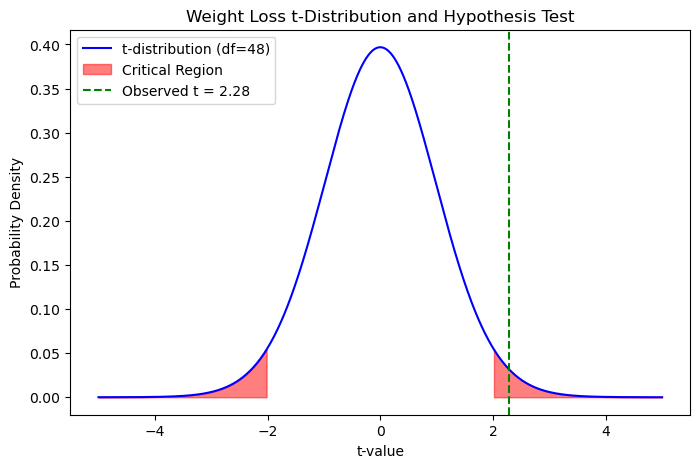

In [32]:
df = n_Trad + n_New - 2  # Degrees of freedom
x = np.linspace(-5, 5, 1000)
t_dist = stats.t.pdf(x, df)

plt.figure(figsize=(8, 5))
plt.plot(x, t_dist, label=f"t-distribution (df={df})", color='blue')

alpha = 0.05
t_critical = stats.t.ppf(1 - alpha/2, df)

plt.fill_between(x, t_dist, where=(x >= t_critical), color='red', alpha=0.5, label='Critical Region')
plt.fill_between(x, t_dist, where=(x <= -t_critical), color='red', alpha=0.5)

plt.axvline(t_stat, color='green', linestyle='--', label=f'Observed t = {t_stat:.2f}')

plt.title("Weight Loss t-Distribution and Hypothesis Test")
plt.xlabel("t-value")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

5. **Conclude whether the new diet plan has a statistically significant effect on weight loss.**

We can conclude that since the p-value $p = 0.03$ is less than the given value for alpha $\alpha = 0.05$ the new diet significantly increased weight loss.

## Story 2 - Two-Sample z-Test: Evaluating the Effectiveness of a New Training Program
A company wants to determine whether a newly implemented productivity training program significantly increases employees’ daily task completion compared to the standard training method. The HR department collects productivity data (average number of tasks completed per day) from two different groups of randomly selected 50 employees:
- Group A: Employees who completed the new productivity training program.
- Group B: Employees who completed the standard training program.

The goal is to determine whether the new training program leads to a significantly higher average
number of tasks completed per day. 

1. **Formulate hypotheses.**

Null Hypothesis $H_0$: There is no significant difference in productivity (task completion rate) between individuals taking the standard training and those taking the new training.

$\mu_{new} = \mu_{standard}$

Alternative Hypothesis $H_1$: The productivity (task completion rate) of individuals taking the new training is significantly greator than that of those taking the standard training.

$\mu_{new} > \mu_{standard}$

2. **Use Python to generate 50 random data points for each group. Assuming:**
   - **Group A (new training) has a mean productivity of 28 tasks/day with a standard deviation of 5 tasks/day.**
   - **Group B (standard training) has a mean productivity of 25 tasks/day with a standard deviation of 5 tasks/day.**

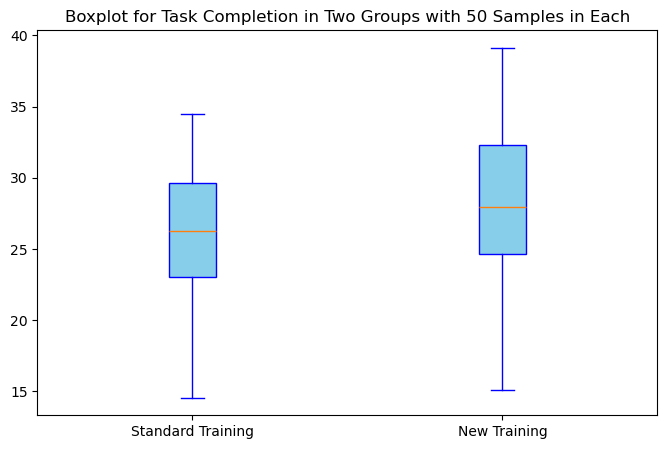

In [33]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(24)

n_Std, n_New = 50, 50 # Sample sizes
mu_Std, mu_New = 25, 28 # Means
sigma_Std, sigma_New = 5, 5 # Standard deviations

sample_Std = np.random.normal(mu_Std, sigma_Std, n_Std)
sample_New = np.random.normal(mu_New, sigma_New, n_New)

plt.figure(figsize=(8, 5))
plt.boxplot([sample_Std, sample_New], tick_labels=["Standard Training", "New Training"],
            patch_artist=True, boxprops=dict(facecolor='skyblue', color='blue'),
            whiskerprops=dict(color='blue'), capprops=dict(color='blue'))
plt.title("Boxplot for Task Completion in Two Groups with 50 Samples in Each")
plt.show()

3. **Perform a two-sample, one-tailed z-test.**

In [29]:
mean_Std, mean_New = np.mean(sample_Std), np.mean(sample_New)
se_Std, se_New = sigma_Std / np.sqrt(n_Std), sigma_New / np.sqrt(n_New)

z_stat = (mean_Std - mean_New) / np.sqrt(se_Std**2 + se_New**2)
p_value = stats.norm.cdf(z_stat)  # One-sided p-value

print(f"Z-Statistic: \n {np.round(z_stat, 2)}")
print(f"P-Value: \n {np.round(p_value, 2)}")

Z-Statistic: 
 -2.47
P-Value: 
 0.01


4. **Plot the Normal Distribution and Critical Value**

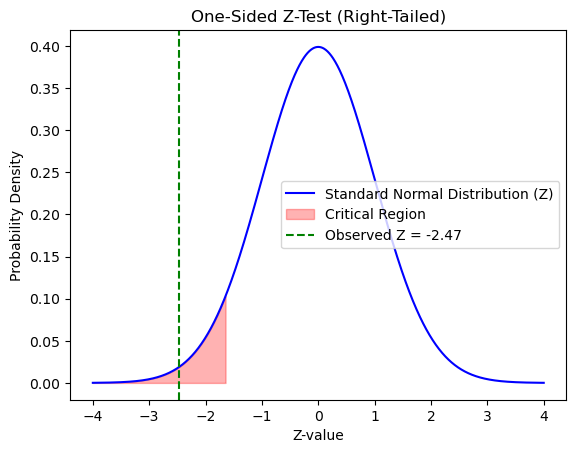

In [30]:
x = np.linspace(-4, 4, 1000)
z_dist = stats.norm.pdf(x)

plt.plot(x, z_dist, label="Standard Normal Distribution (Z)", color="blue")
z_critical = stats.norm.ppf(0.05)  # Right-tailed critical value at alpha = 0.05
plt.fill_between(x, z_dist, where=(x <= z_critical), color="red", alpha=0.3, label="Critical Region")
plt.axvline(z_stat, color="green", linestyle="--", label=f"Observed Z = {z_stat:.2f}")
plt.title("One-Sided Z-Test (Right-Tailed)")
plt.xlabel("Z-value")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

5. **Based on the computed p-value and Z-score, determine whether to reject or fail to reject the null hypothesis. Discuss whether the new training program significantly improves productivity.**

Based on the computed p-value $p = .01$ and Z-score $Z = -2.47$, we can, with a great deal of certainty reject the null hypothesis. This means the new training program has a significant impact on productivity (task completion).